# Performance by Variance Bucket

Analyze the old CRC 1000-gene experiment, grouping genes into buckets by variance (std_expr) and examining mean Pearson r in each bucket.

**Goal:** Show clearly that variance is the best predictor of gene predictability.

**Prerequisite:** Run `analyze_old_crc_variance.ipynb` first to generate `old_crc_variance_analysis.csv`.

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats

PROJECT = Path('/hpc/group/jilab/tc459/MorphPT')
CSV     = PROJECT / 'analysis/old_crc_variance_analysis.csv'

df = pd.read_csv(CSV)

print(f'Loaded {len(df)} genes')
print(f'std_expr range: [{df["std_expr"].min():.3f}, {df["std_expr"].max():.3f}]')

plt.rcParams.update({
    'figure.dpi': 120, 'font.size': 9,
    'axes.spines.top': False, 'axes.spines.right': False,
    'legend.frameon': False,
})

Loaded 1000 genes
std_expr range: [0.244, 2.220]


## 1. Quantile-based variance buckets (equal-sized)

Split genes into 5 equal-sized buckets by std_expr (each with ~200 genes).

In [2]:
# 5 quantile-based buckets — each contains 20% of genes
df['var_quintile'] = pd.qcut(df['std_expr'], q=5,
                              labels=['Q1 (lowest)',  'Q2',
                                      'Q3 (median)',  'Q4',
                                      'Q5 (highest)'])

summary_q = df.groupby('var_quintile', observed=True).agg(
    n_genes          = ('test_r',   'count'),
    std_min          = ('std_expr', 'min'),
    std_max          = ('std_expr', 'max'),
    coverage_mean    = ('coverage', 'mean'),
    mean_pearson     = ('test_r',   'mean'),
    median_pearson   = ('test_r',   'median'),
    frac_r_gt_01     = ('test_r',   lambda s: (s > 0.1).mean()),
    frac_r_gt_02     = ('test_r',   lambda s: (s > 0.2).mean()),
    frac_r_gt_03     = ('test_r',   lambda s: (s > 0.3).mean()),
).round(3)

print('Performance by variance quintile:')
print(summary_q.to_string())

Performance by variance quintile:
              n_genes  std_min  std_max  coverage_mean  mean_pearson  median_pearson  frac_r_gt_01  frac_r_gt_02  frac_r_gt_03
var_quintile                                                                                                                  
Q1 (lowest)       200    0.244    0.362          0.014         0.200           0.194         0.935         0.430         0.070
Q2                200    0.362    0.462          0.024         0.219           0.217         0.940         0.600         0.140
Q3 (median)       200    0.462    0.593          0.041         0.254           0.244         0.965         0.615         0.305
Q4                200    0.594    0.816          0.074         0.284           0.248         0.990         0.700         0.410
Q5 (highest)      200    0.818    2.220          0.180         0.359           0.309         0.995         0.900         0.535


## 2. Fixed variance thresholds

Use absolute std_expr cutoffs that might be more interpretable.

In [3]:
bins   = [0, 0.3, 0.5, 0.8, 1.2, 10.0]
labels = ['<0.3', '0.3-0.5', '0.5-0.8', '0.8-1.2', '>1.2']

df['var_bin'] = pd.cut(df['std_expr'], bins=bins, labels=labels)

summary_f = df.groupby('var_bin', observed=True).agg(
    n_genes          = ('test_r',   'count'),
    coverage_mean    = ('coverage', 'mean'),
    mean_pearson     = ('test_r',   'mean'),
    median_pearson   = ('test_r',   'median'),
    frac_r_gt_02     = ('test_r',   lambda s: (s > 0.2).mean()),
    frac_r_gt_03     = ('test_r',   lambda s: (s > 0.3).mean()),
    frac_r_gt_05     = ('test_r',   lambda s: (s > 0.5).mean()),
).round(3)

print('Performance by fixed std_expr bins:')
print(summary_f.to_string())

Performance by fixed std_expr bins:
         n_genes  coverage_mean  mean_pearson  median_pearson  frac_r_gt_02  frac_r_gt_03  frac_r_gt_05
var_bin                                                                                                
<0.3          51          0.011         0.178           0.172         0.275         0.059         0.000
0.3-0.5      399          0.021         0.218           0.212         0.559         0.128         0.013
0.5-0.8      341          0.060         0.273           0.247         0.663         0.381         0.050
0.8-1.2      175          0.155         0.324           0.285         0.869         0.440         0.131
>1.2          34          0.291         0.506           0.457         1.000         0.912         0.412


## 3. Visualization

/tmp/ipykernel_46827/238418682.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp        = ax.boxplot(q_data, labels=q_with_n, patch_artist=True,


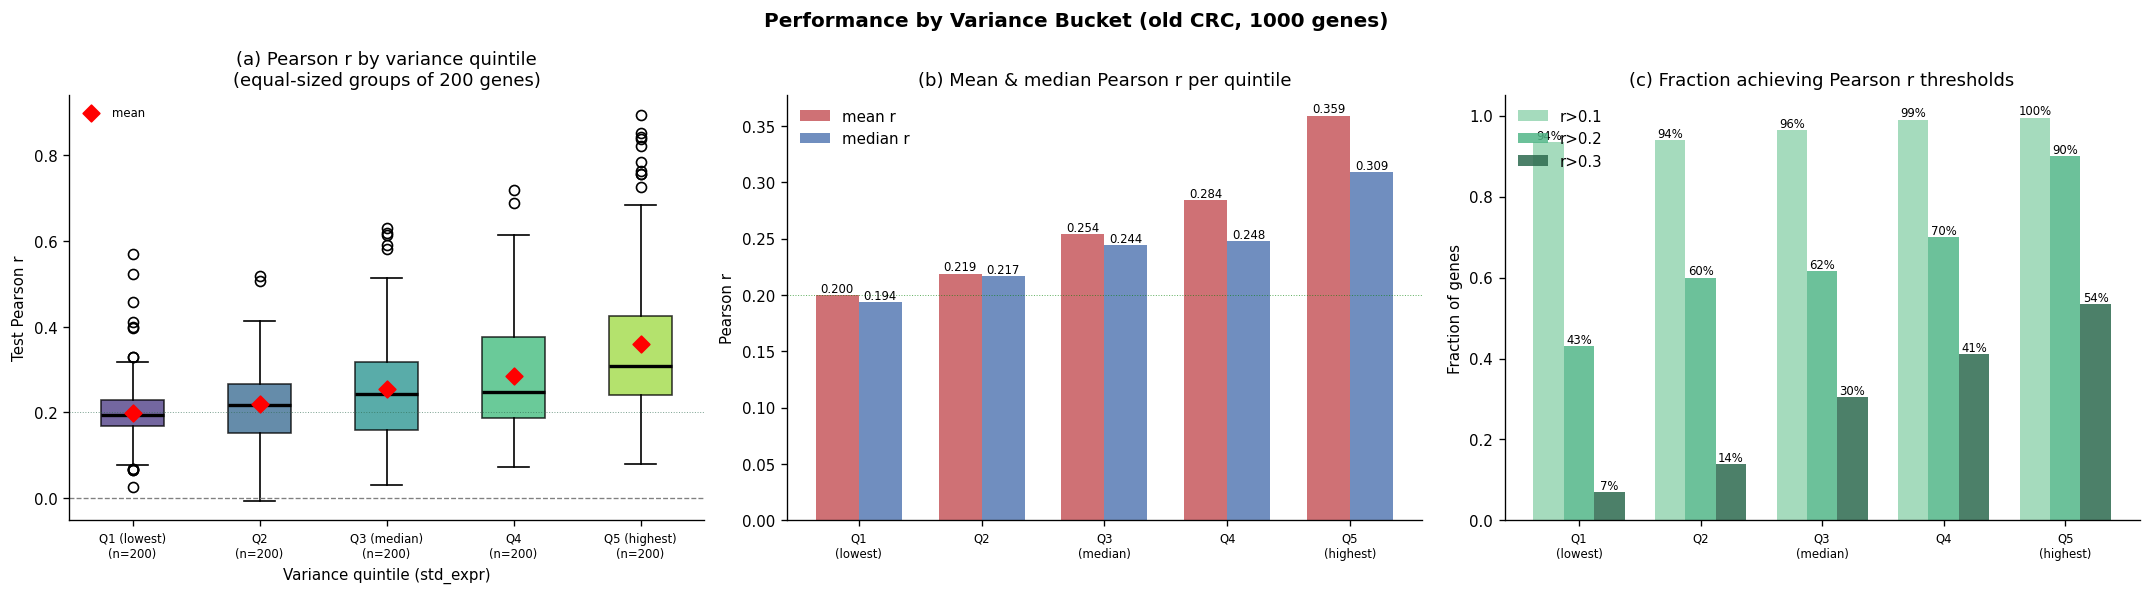

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (a) Boxplot by quintile
ax = axes[0]
q_labels  = summary_q.index.tolist()
q_data    = [df[df['var_quintile']==q]['test_r'].values for q in q_labels]
q_with_n  = [f'{q}\n(n={len(d)})' for q, d in zip(q_labels, q_data)]
bp        = ax.boxplot(q_data, labels=q_with_n, patch_artist=True,
                       medianprops=dict(color='black', lw=2))
colors = plt.cm.viridis(np.linspace(0.15, 0.85, 5))
for patch, c in zip(bp['boxes'], colors):
    patch.set_facecolor(c)
    patch.set_alpha(0.75)

# Show means as red diamonds
means = [np.mean(d) for d in q_data]
ax.scatter(range(1, len(means)+1), means,
           color='red', marker='D', s=50, zorder=5, label='mean')

ax.axhline(0,   color='gray',   lw=0.8, ls='--')
ax.axhline(0.2, color='#2d6a4f', lw=0.6, ls=':', alpha=0.6)
ax.set_ylabel('Test Pearson r')
ax.set_xlabel('Variance quintile (std_expr)')
ax.set_title('(a) Pearson r by variance quintile\n(equal-sized groups of 200 genes)')
ax.tick_params(axis='x', labelsize=7)
ax.legend(fontsize=7)

# (b) Mean & median bar chart with coverage overlay
ax  = axes[1]
x   = np.arange(len(summary_q))
w   = 0.35
b1  = ax.bar(x - w/2, summary_q['mean_pearson'],   w,
             label='mean r',   color='#C44E52', alpha=0.8)
b2  = ax.bar(x + w/2, summary_q['median_pearson'], w,
             label='median r', color='#4C72B0', alpha=0.8)

# Annotate values
for b in b1:
    ax.annotate(f'{b.get_height():.3f}',
                xy=(b.get_x() + b.get_width()/2, b.get_height()),
                ha='center', va='bottom', fontsize=7)
for b in b2:
    ax.annotate(f'{b.get_height():.3f}',
                xy=(b.get_x() + b.get_width()/2, b.get_height()),
                ha='center', va='bottom', fontsize=7)

ax.set_xticks(x)
ax.set_xticklabels([q.replace(' ', '\n') for q in q_labels],
                   fontsize=7)
ax.axhline(0.2, color='green', lw=0.6, ls=':', alpha=0.6)
ax.set_ylabel('Pearson r')
ax.set_title('(b) Mean & median Pearson r per quintile')
ax.legend()

# (c) Stacked fraction of genes achieving thresholds
ax   = axes[2]
frac_data = summary_q[['frac_r_gt_01',
                       'frac_r_gt_02',
                       'frac_r_gt_03']].copy()
frac_data.columns = ['r>0.1', 'r>0.2', 'r>0.3']

x     = np.arange(len(frac_data))
bwidth= 0.25
for i, col in enumerate(frac_data.columns):
    shade = ['#95d5b2', '#52b788', '#2d6a4f'][i]
    bars  = ax.bar(x + (i - 1) * bwidth, frac_data[col], bwidth,
                   label=col, color=shade, alpha=0.85)
    for b in bars:
        ax.annotate(f'{b.get_height():.0%}',
                    xy=(b.get_x() + b.get_width()/2, b.get_height()),
                    ha='center', va='bottom', fontsize=7)

ax.set_xticks(x)
ax.set_xticklabels([q.replace(' ', '\n') for q in q_labels],
                   fontsize=7)
ax.set_ylabel('Fraction of genes')
ax.set_title('(c) Fraction achieving Pearson r thresholds')
ax.legend(loc='upper left')
ax.set_ylim(0, 1.05)

fig.suptitle('Performance by Variance Bucket (old CRC, 1000 genes)',
             fontweight='bold', fontsize=12)
fig.tight_layout()
plt.show()

## 4. Variance effect controlling for coverage

Within each coverage bin, split further by variance to show variance effect is NOT driven by coverage.

Mean Pearson r by (coverage × variance) bucket:

Mean Pearson r:
var_quartile  low var  mid-low var  mid-high var  high var
cov_bin                                                   
cov<5%          0.202        0.235         0.338     0.359
cov 5-15%         NaN        0.160         0.235     0.354
cov 15-30%        NaN          NaN           NaN     0.316
cov>30%           NaN          NaN           NaN     0.427

N genes in each cell:
var_quartile  low var  mid-low var  mid-high var  high var
cov_bin                                                   
cov<5%          250.0        243.0          96.0       3.0
cov 5-15%         NaN          7.0         154.0     131.0
cov 15-30%        NaN          NaN           NaN      99.0
cov>30%           NaN          NaN           NaN      17.0


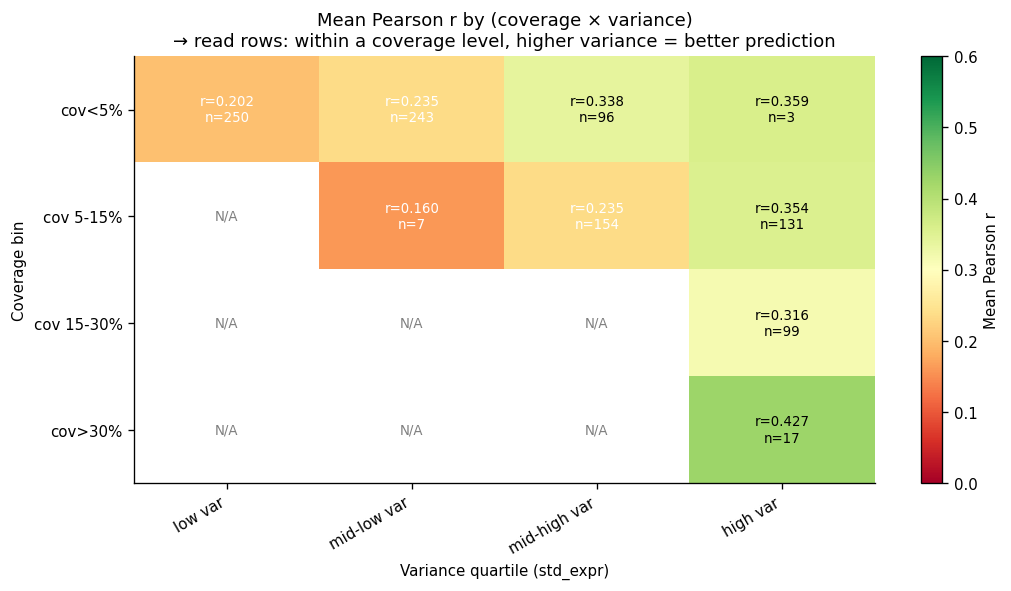

In [5]:
# Create coverage buckets
cov_bins   = [0, 0.05, 0.15, 0.30, 1.01]
cov_labels = ['cov<5%', 'cov 5-15%', 'cov 15-30%', 'cov>30%']
df['cov_bin'] = pd.cut(df['coverage'], bins=cov_bins, labels=cov_labels)

# Create variance buckets (within each coverage bin)
# Use global quartiles for std_expr
df['var_quartile'] = pd.qcut(df['std_expr'], q=4,
                              labels=['low var', 'mid-low var',
                                      'mid-high var', 'high var'])

# Cross-tabulate
ct = df.groupby(['cov_bin', 'var_quartile'], observed=True).agg(
    n           = ('test_r', 'count'),
    mean_r      = ('test_r', 'mean'),
).round(3)

print('Mean Pearson r by (coverage × variance) bucket:')
print()

# Pivot table view
pivot_r = df.pivot_table(index='cov_bin', columns='var_quartile',
                          values='test_r', aggfunc='mean', observed=True).round(3)
pivot_n = df.pivot_table(index='cov_bin', columns='var_quartile',
                          values='test_r', aggfunc='count', observed=True)

print('Mean Pearson r:')
print(pivot_r.to_string())
print('\nN genes in each cell:')
print(pivot_n.to_string())

# Heatmap
fig, ax = plt.subplots(figsize=(9, 5))
im = ax.imshow(pivot_r.values, cmap='RdYlGn', aspect='auto',
               vmin=0, vmax=0.6)
ax.set_xticks(range(len(pivot_r.columns)))
ax.set_xticklabels(pivot_r.columns, rotation=30, ha='right')
ax.set_yticks(range(len(pivot_r.index)))
ax.set_yticklabels(pivot_r.index)
ax.set_xlabel('Variance quartile (std_expr)')
ax.set_ylabel('Coverage bin')
ax.set_title('Mean Pearson r by (coverage × variance)\n'
             '→ read rows: within a coverage level, higher variance = better prediction')

# Annotate cells with mean_r (n)
for i in range(len(pivot_r.index)):
    for j in range(len(pivot_r.columns)):
        v = pivot_r.iloc[i, j]
        n = pivot_n.iloc[i, j]
        if not np.isnan(v):
            color = 'white' if v < 0.25 else 'black'
            ax.text(j, i, f'r={v:.3f}\nn={int(n)}',
                    ha='center', va='center', color=color, fontsize=8)
        else:
            ax.text(j, i, 'N/A', ha='center', va='center',
                    color='gray', fontsize=8)

plt.colorbar(im, ax=ax, label='Mean Pearson r')
fig.tight_layout()
plt.show()

## 5. Key Takeaway

Look at the heatmap above. Each **row** represents a fixed coverage level. Within each row:
- Left (low variance) → low Pearson r
- Right (high variance) → high Pearson r

**If moving right in a row increases Pearson r substantially, that's evidence that variance — not coverage — drives predictability.**

In [6]:
print(f'{"="*65}')
print(f'SUMMARY: Performance by Variance Bucket')
print(f'{"="*65}')
print()
print('Variance quintile effect on Pearson r:')
print(f'  Q1 (lowest variance):  mean r = {summary_q.iloc[0]["mean_pearson"]:.3f}')
print(f'  Q5 (highest variance): mean r = {summary_q.iloc[-1]["mean_pearson"]:.3f}')
delta = summary_q.iloc[-1]['mean_pearson'] - summary_q.iloc[0]['mean_pearson']
print(f'  Q5 - Q1 delta:         {delta:+.3f}  ({delta/summary_q.iloc[0]["mean_pearson"]*100:+.0f}%)')
print()

# Coverage effect within same variance for comparison
cov_effect = df.groupby(pd.qcut(df['coverage'], q=5, duplicates='drop'),
                         observed=True)['test_r'].mean()
print(f'For comparison — Coverage quintile effect:')
print(f'  Lowest coverage:  mean r = {cov_effect.iloc[0]:.3f}')
print(f'  Highest coverage: mean r = {cov_effect.iloc[-1]:.3f}')
cov_delta = cov_effect.iloc[-1] - cov_effect.iloc[0]
print(f'  Delta:            {cov_delta:+.3f}  ({cov_delta/cov_effect.iloc[0]*100:+.0f}%)')
print()

if delta > cov_delta:
    print(f'→ Variance is a STRONGER predictor of predictability than coverage')
    print(f'  (delta {delta:.3f} vs {cov_delta:.3f})')
else:
    print(f'→ Coverage is slightly stronger than variance')

SUMMARY: Performance by Variance Bucket

Variance quintile effect on Pearson r:
  Q1 (lowest variance):  mean r = 0.200
  Q5 (highest variance): mean r = 0.359
  Q5 - Q1 delta:         +0.159  (+79%)

For comparison — Coverage quintile effect:
  Lowest coverage:  mean r = 0.211
  Highest coverage: mean r = 0.322
  Delta:            +0.110  (+52%)

→ Variance is a STRONGER predictor of predictability than coverage
  (delta 0.159 vs 0.110)
